In [21]:
import sys
sys.path.insert(0, "..")

import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
from torchvision.io import read_image, ImageReadMode

from src.data.components.transforms import NoCropTransforms

In [22]:
# Load dataset
train_path = "/Users/lukasb/Documents/data/surfaceClassification/full_clean_clustered_new/train"
ds = ImageFolder(train_path)

print(f"Total images: {len(ds)}")
print(f"Classes: {ds.classes}")
print(f"Class counts: {dict(zip(ds.classes, torch.bincount(torch.tensor(ds.targets)).tolist()))}")

Total images: 3853
Classes: ['background', 'black_stain', 'corrosion', 'crack', 'deformation', 'missing_part', 'ok', 'other', 'silicate_stain', 'water_stain']
Class counts: {'background': 243, 'black_stain': 122, 'corrosion': 472, 'crack': 204, 'deformation': 1489, 'missing_part': 221, 'ok': 683, 'other': 126, 'silicate_stain': 64, 'water_stain': 229}


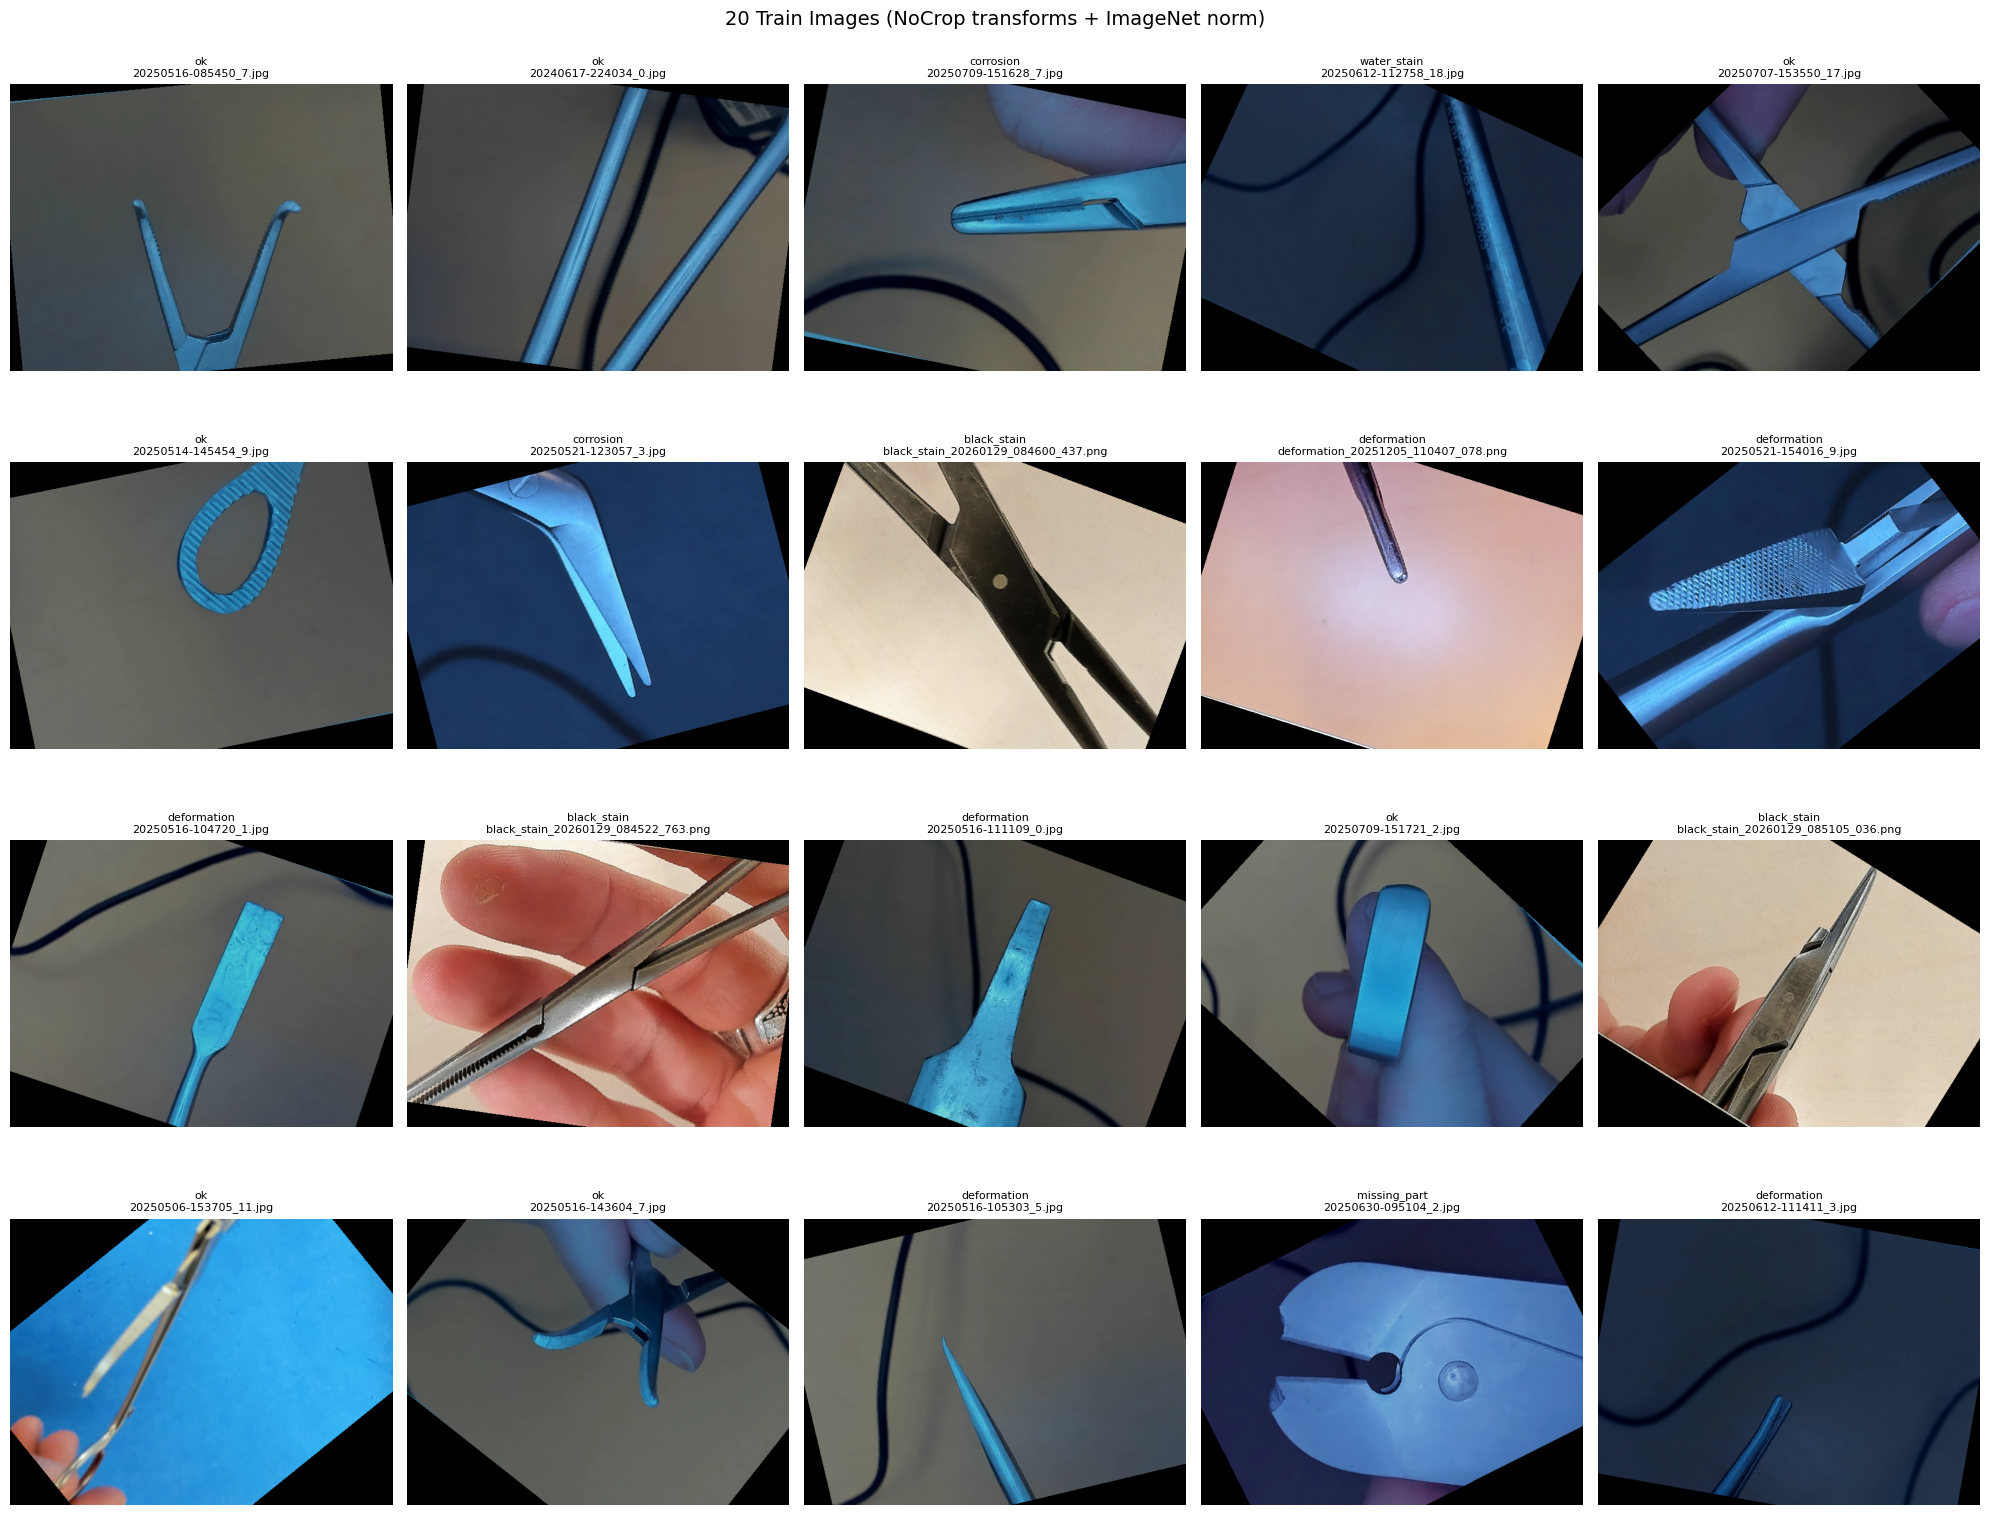

In [23]:
# Replicate the pipeline from holdout_datamodule with no_crop transforms
train_transforms = NoCropTransforms.train_transforms()
resize = v2.Resize(480, antialias=True)
to_float = v2.ToDtype(torch.float32, scale=True)

# ImageNet normalization (same as datamodule with image1k_norm=True)
im_1k_mean = [0.485, 0.456, 0.406]
im_1k_std = [0.229, 0.224, 0.225]
norm = v2.Normalize(mean=im_1k_mean, std=im_1k_std)

# Pick 20 random images
rng = np.random.default_rng(42)
indices = rng.choice(len(ds), size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, idx in enumerate(indices):
    path, label = ds.samples[idx]
    class_name = ds.classes[label]
    
    # Load image like TransformSubset does
    img = read_image(path, mode=ImageReadMode.RGB)  # uint8 tensor
    
    # Apply transforms like on_after_batch_transfer does:
    # 1. geometric transforms (per-image)
    img = train_transforms(img)
    # 2. resize
    img = resize(img)
    # 3. to float [0,1]
    img = to_float(img)
    # 4. normalize
    img_normed = norm(img)
    
    # For display: denormalize back to [0,1]
    mean_t = torch.tensor(im_1k_mean).view(3, 1, 1)
    std_t = torch.tensor(im_1k_std).view(3, 1, 1)
    img_display = img_normed * std_t + mean_t
    img_display = img_display.clamp(0, 1)
    
    axes[i].imshow(img_display.permute(1, 2, 0).numpy())
    axes[i].set_title(f"{class_name}\n{path.split('/')[-1]}", fontsize=8)
    axes[i].axis("off")

plt.suptitle("20 Train Images (NoCrop transforms + ImageNet norm)", fontsize=14)
plt.tight_layout()
plt.show()

=== Class Distribution per Split ===


split,train,val,test,total,train_%,val_%,test_%
class,,,,,,,
background,215,53,81,349,61.6,15.2,23.2
black_stain,125,32,34,191,65.4,16.8,17.8
corrosion,493,182,128,803,61.4,22.7,15.9
crack,183,40,82,305,60.0,13.1,26.9
deformation,2021,277,203,2501,80.8,11.1,8.1
deleted,22,0,0,22,100.0,0.0,0.0
missing_part,264,45,88,397,66.5,11.3,22.2
ok,758,112,109,979,77.4,11.4,11.1
other,216,36,21,273,79.1,13.2,7.7



=== Overall Split Distribution (n=6348) ===


,count,%
split,,
train,4682,73.8
val,850,13.4
test,816,12.9


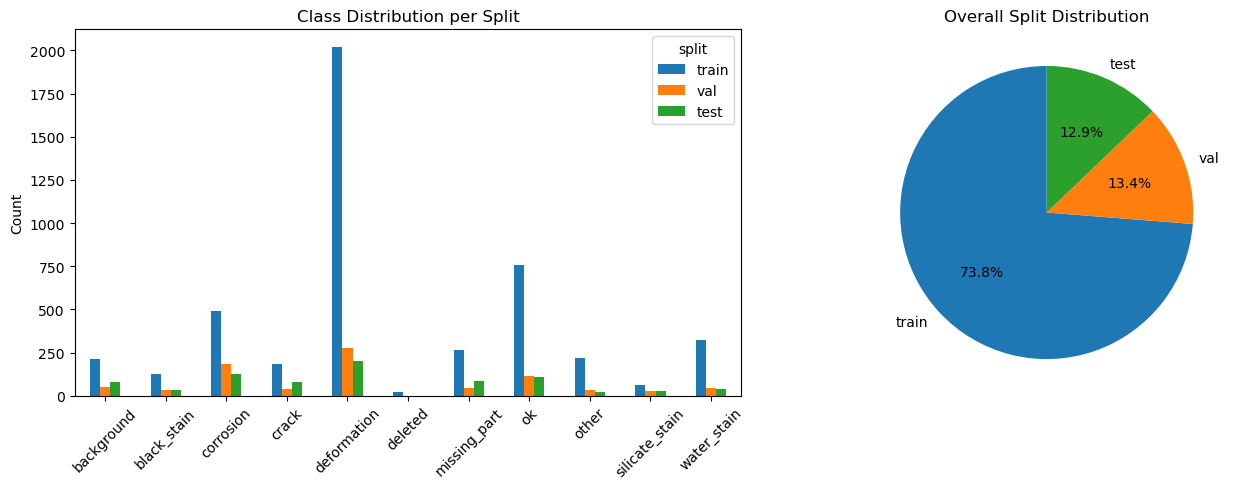

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

base_path = "/Users/lukasb/Documents/data/surfaceClassification/full_clean_temporal_new"
splits = ["train", "val", "test"]

# Collect counts per split
records = []
for split in splits:
    ds = ImageFolder(f"{base_path}/{split}")
    counts = {}
    for _, label in ds.samples:
        name = ds.classes[label]
        counts[name] = counts.get(name, 0) + 1
    for cls, count in counts.items():
        records.append({"split": split, "class": cls, "count": count})

df = pd.DataFrame(records)
pivot = df.pivot(index="class", columns="split", values="count").fillna(0).astype(int)
pivot = pivot[splits]  # ensure column order
pivot["total"] = pivot.sum(axis=1)

# Add split percentages
for s in splits:
    pivot[f"{s}_%"] = (pivot[s] / pivot["total"] * 100).round(1)

# Overall split distribution
totals = pivot[splits].sum()
total_all = totals.sum()
summary = pd.DataFrame({
    "count": totals,
    "%": (totals / total_all * 100).round(1),
})

print("=== Class Distribution per Split ===")
display(pivot)
print(f"\n=== Overall Split Distribution (n={int(total_all)}) ===")
display(summary)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot[splits].plot(kind="bar", ax=axes[0])
axes[0].set_title("Class Distribution per Split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].pie(totals, labels=splits, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Overall Split Distribution")

plt.tight_layout()
plt.show()

In [27]:
# Target: 70/15/15 split per class
# Shows how many samples to ADD to val/test (negative = has surplus)
target_val_pct = 0.15
target_test_pct = 0.15

targets = []
for cls in pivot.index:
    total = pivot.loc[cls, "total"]
    train_n = pivot.loc[cls, "train"]
    val_n = pivot.loc[cls, "val"]
    test_n = pivot.loc[cls, "test"]
    
    target_val = round(total * target_val_pct)
    target_test = round(total * target_test_pct)
    
    targets.append({
        "class": cls,
        "train": train_n,
        "val_current": val_n,
        "val_target": target_val,
        "val_delta": target_val - val_n,
        "test_current": test_n,
        "test_target": target_test,
        "test_delta": target_test - test_n,
    })

target_df = pd.DataFrame(targets).set_index("class")
print("=== Samples to add (+) or remove (-) per class ===")
display(target_df)

=== Samples to add (+) or remove (-) per class ===


,train,val_current,val_target,val_delta,test_current,test_target,test_delta
class,,,,,,,
background,215,53,52,-1,81,52,-29
black_stain,125,32,29,-3,34,29,-5
corrosion,493,182,120,-62,128,120,-8
crack,183,40,46,6,82,46,-36
deformation,2021,277,375,98,203,375,172
deleted,22,0,3,3,0,3,3
missing_part,264,45,60,15,88,60,-28
ok,758,112,147,35,109,147,38
other,216,36,41,5,21,41,20
